# Customer Churn Prediction & Retention Strategy

## Introduction

Customer churn is one of the most critical challenges for subscription-based businesses. When customers leave, companies not only lose recurring revenue but also incur additional costs to acquire new users.

In highly competitive markets, even small improvements in customer retention can have a significant impact on profitability. As a result, organizations increasingly rely on data-driven approaches to understand, predict, and prevent churn.

This project aims to build a machine learning system that not only predicts which customers are likely to churn, but also explains why and provides actionable strategies to reduce customer loss.

---

## Real-World Scenario

Imagine a telecommunications company operating in a competitive market with thousands of customers on different subscription plans.

Each month, a portion of customers cancels their service. The company faces several challenges:

- It does not know in advance which customers are likely to leave  
- Retention campaigns are applied uniformly, leading to inefficient use of budget  
- High-value customers may leave without targeted intervention  
- Customer behavior patterns are not fully understood  

To address these issues, the company wants to:

1. Identify customers at high risk of churn  
2. Understand the main drivers behind churn behavior  
3. Design targeted retention strategies  
4. Allocate retention resources efficiently to maximize ROI  

---

## Project Objective

The objective of this project is to develop an end-to-end churn prediction and decision-support system that:

- Predicts customer churn using machine learning models  
- Provides explainability through feature importance and SHAP analysis  
- Segments customers based on risk and value  
- Recommends targeted retention actions  
- Estimates the financial impact of these actions through ROI simulation  

By combining predictive analytics with business logic, the project demonstrates how machine learning can support real-world decision-making and improve customer retention strategies.

## Problem to Solve

Which customers are likely to churn, and how can we intervene profitably?

# Step 1: Data Loading and Initial Inspection
## Objective: Load the dataset, validate structure, and ensure data quality

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
#Import the libraries necessary to STEP 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load the dataset and inspect the first five rows

In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#Preliminary data inspection

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#Check for Missing Values

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
#Change object into float

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
#Target Variable Count and Proportions

In [14]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [15]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


# Step 2: Exploratory Data Analysis (EDA)
## Objective: Understand patterns, detect drivers of churn, and generate business insights

The objective is to address three key questions:

- What is the overall level of churn?
- Which customer segments are most prone to churn?
- Which features are likely to be most informative for modeling?

In [16]:
#2.1: DATASET OVERVIEW

In [17]:
print(df.shape)
print('-------------------')
display(df.head())
print('--------------------')
print(df.dtypes)
print('--------------------')
print(df.isnull().sum())
print('--------------------')
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

(7043, 21)
-------------------


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
--------------------
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract   

In [18]:
#2.2: TARGET DISTRIBUTION

Churn
No     5174
Yes    1869
Name: count, dtype: int64
-----------------
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


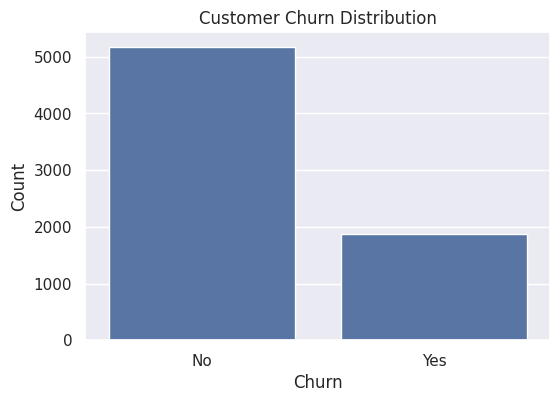

In [19]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print('-----------------')
print(churn_rate)

sns.set()
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

The dataset shows that churn is the minority class, which suggests a class imbalance problem. This is important because accuracy alone may be misleading, and metrics such as recall, precision, and ROC-AUC will be more informative during model evaluation.

In [20]:
#2.3: MISSING VALUES AND DATA QUALITY

In [21]:
print(df['TotalCharges'].isnull().sum())
print('-------------------------------')
df[df['TotalCharges'].isnull()]

11
-------------------------------


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [22]:
df = df.dropna(subset=['TotalCharges']).copy()
print(df.shape)

(7032, 21)


A small number of records had non-numeric or missing values in TotalCharges. Since they represent a very limited portion of the dataset, they were removed to preserve data quality without materially affecting the analysis.

In [23]:
#2.4: NUMERICAL FEATURE DISTRIBUTIONS

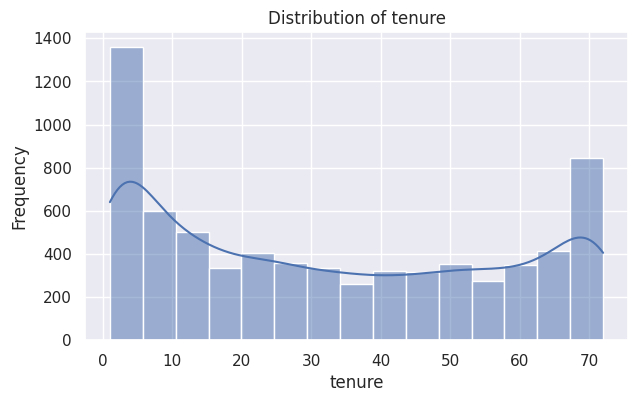

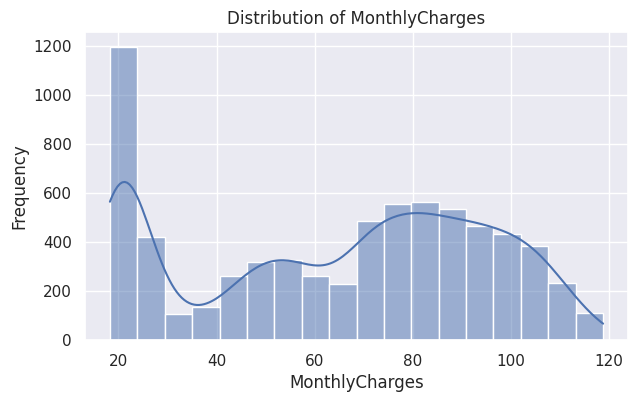

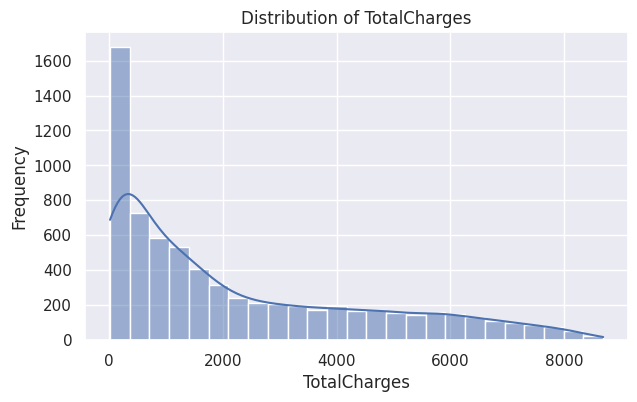

In [24]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [25]:
#2.5: NUMERICAL FEATURES VS. CHURN

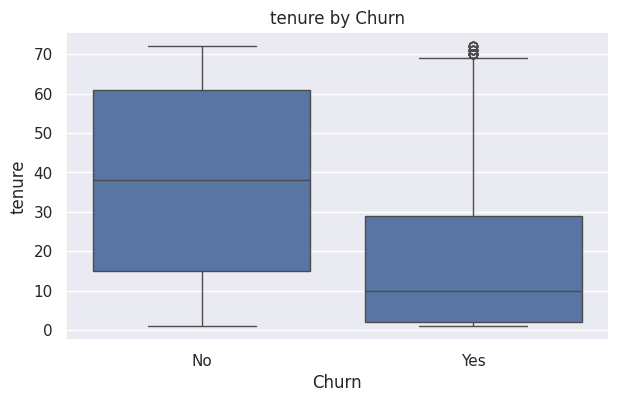

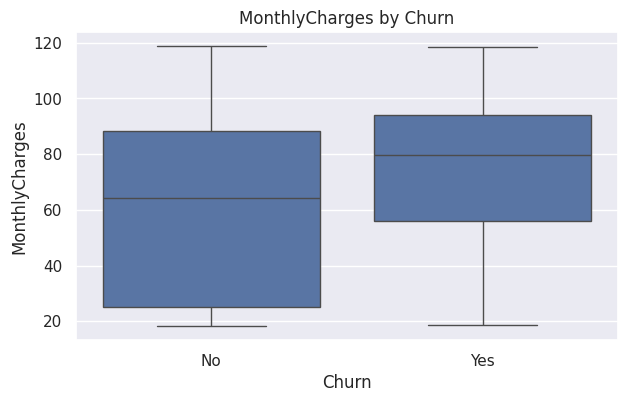

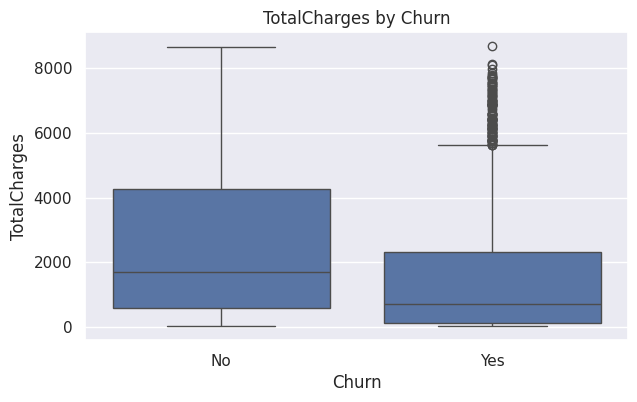

In [26]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

Customers who churn tend to have shorter tenure, suggesting that early customer retention is critical. Monthly charges also appear higher among churned customers, which may indicate price sensitivity or lower perceived value.

In [27]:
#2.6: CATEGORICAL FEATURES VS. CHURN

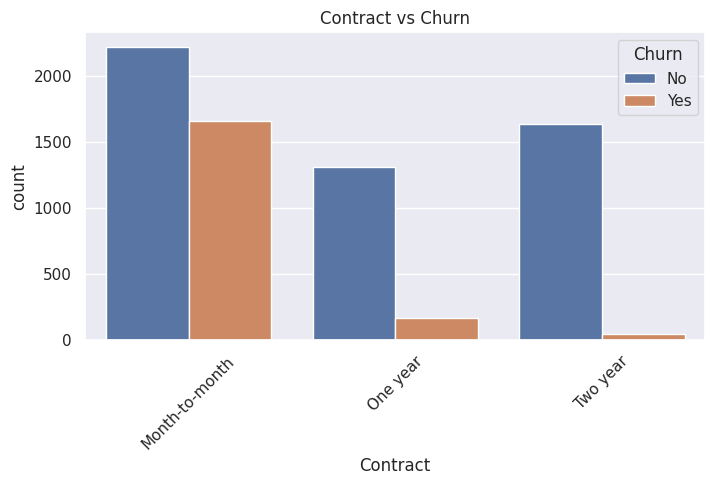

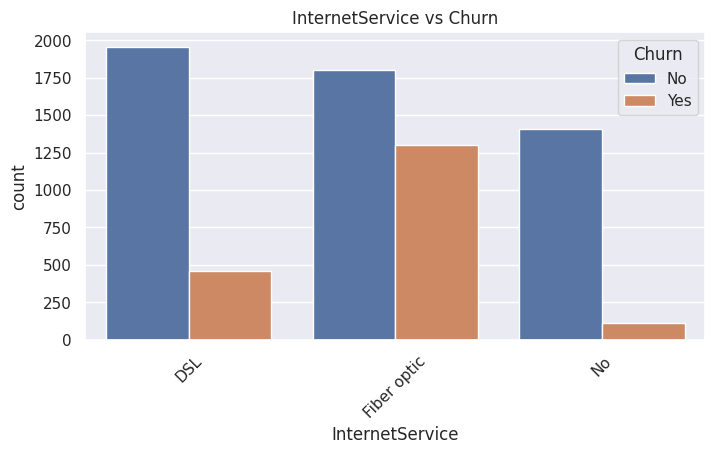

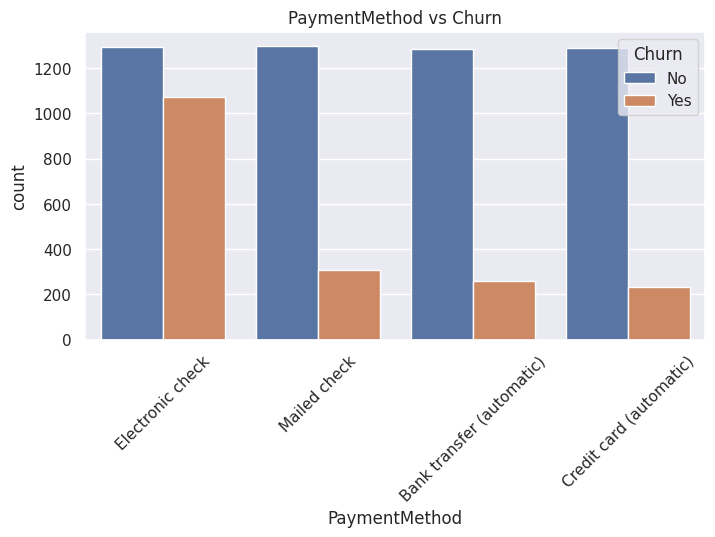

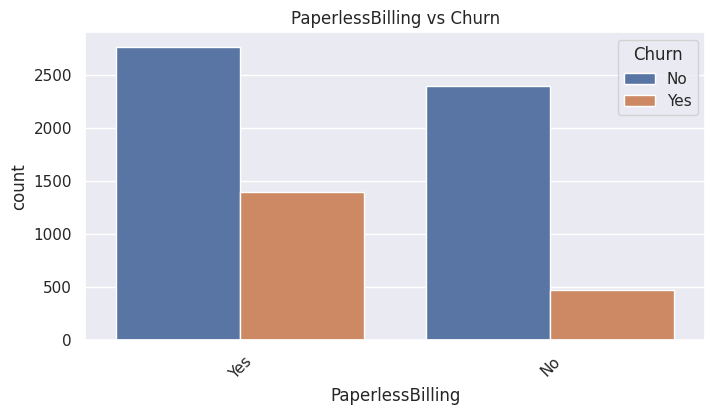

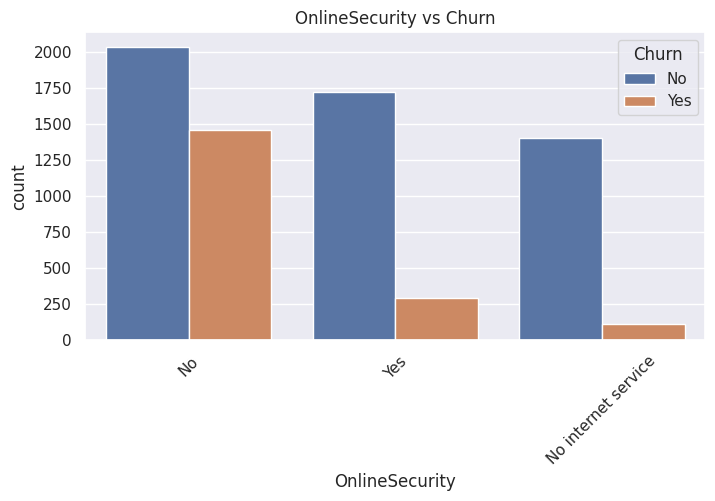

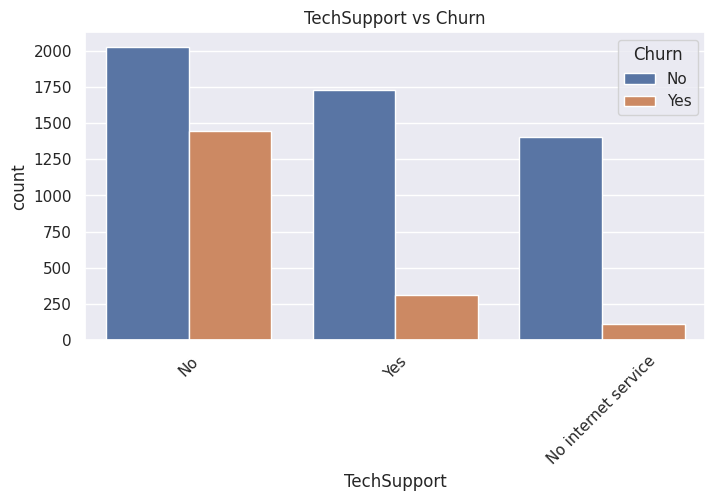

In [28]:
cat_cols = [
    'Contract',
    'InternetService',
    'PaymentMethod',
    'PaperlessBilling',
    'OnlineSecurity',
    'TechSupport'
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

In [29]:
#2.7: CHURN RATE BY CATEGORY

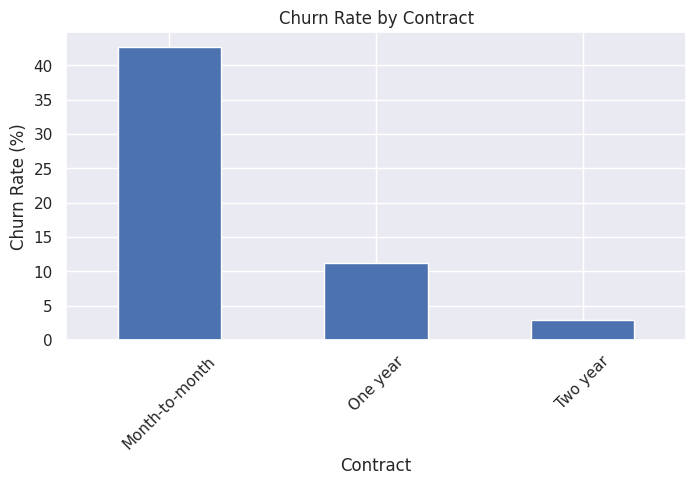

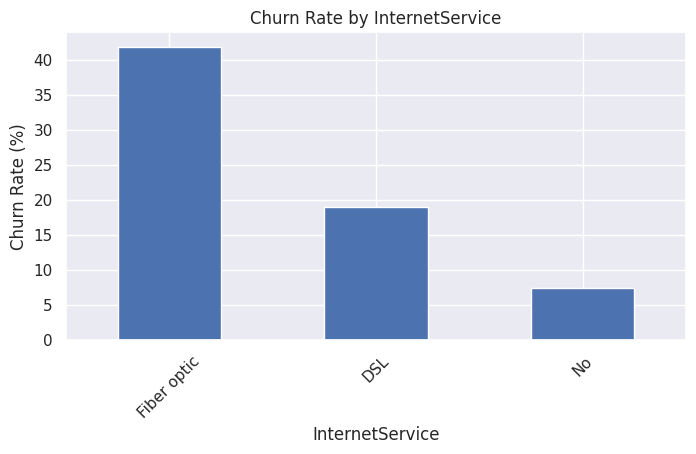

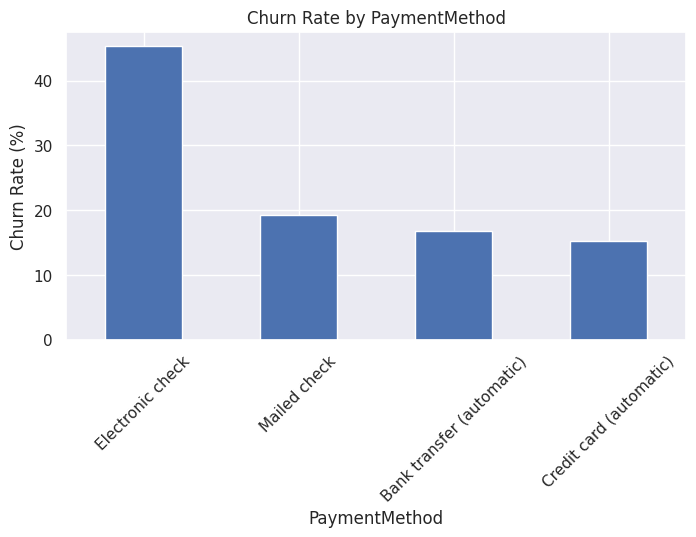

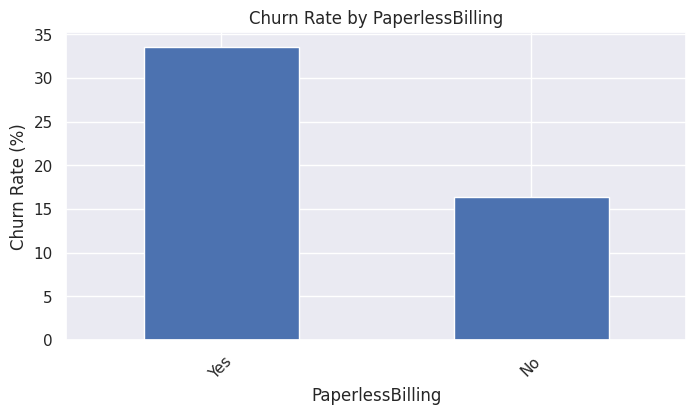

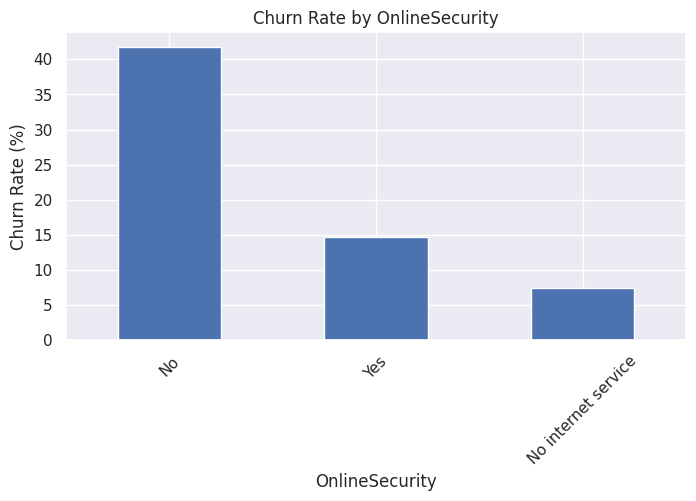

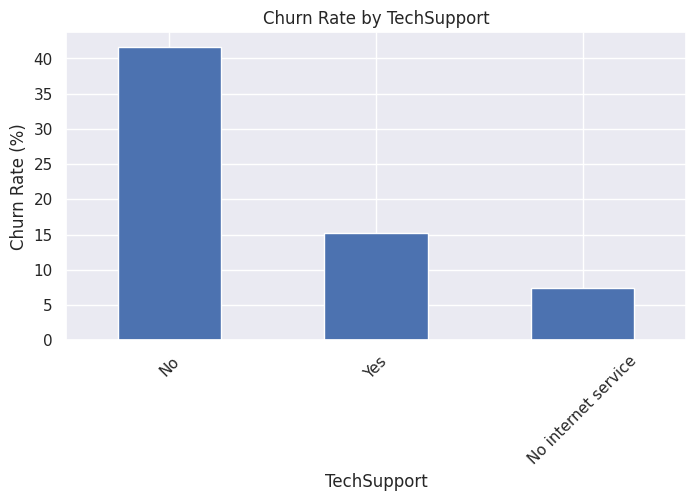

In [30]:
for col in cat_cols:
    churn_by_cat = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100

    if 'Yes' in churn_by_cat.columns:
        churn_by_cat = churn_by_cat.sort_values('Yes', ascending=False)
        churn_by_cat['Yes'].plot(kind='bar', figsize=(8,4))
        plt.title(f'Churn Rate by {col}')
        plt.ylabel('Churn Rate (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.show()

Month-to-month customers show the highest churn rate, making contract type one of the strongest early indicators of customer risk. Customers without online security or tech support also churn more frequently, suggesting that deeper service adoption may improve retention.

In [31]:
#2.8: CORRELATION ANALYSIS

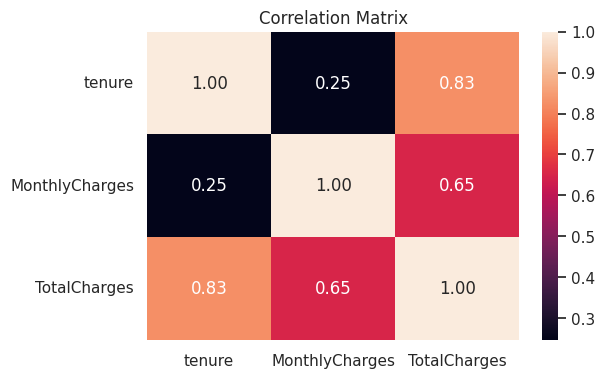

In [32]:
plt.figure(figsize=(6,4))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

TotalCharges is strongly related to tenure and MonthlyCharges, which is expected because it reflects accumulated customer spending over time.

In [33]:
#2.9: INITIAL BUSINESS INSIGHTS

In [34]:
# churn rate by contract
print('Churn Rate by Contract')
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

print('---------------------------------------------------')

# churn rate by internet service
print('Churn Rate by Internet Service')
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn)

print('---------------------------------------------------')

# churn rate by payment method
print('Churn Rate by Payment Method')
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print(payment_churn)

Churn Rate by Contract
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665
---------------------------------------------------
Churn Rate by Internet Service
Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211
---------------------------------------------------
Churn Rate by Payment Method
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


## Insights

1. Newer customers are more likely to churn
2. Month-to-month contracts have the highest churn risk
3. Customers with higher monthly charges and lower service adoption appear more vulnerable

## Summary of Step 2

The EDA shows that churn is not random. It is associated with specific customer behaviors and service choices, especially short tenure, month-to-month contracts, higher monthly charges, and lower adoption of support/security-related services. These patterns provide a strong foundation for feature engineering and predictive modeling.

# Step 3: Feature Engineering
## Objective: Create meaningful features that improve predictive power and capture customer behavior

In [35]:
#3.1: CONVERT TARGET FROM CATEGORICAL TO NUMERIC

In [36]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [37]:
#3.2: TENURE SEGMENTATION IN BUCKETS

In [38]:
def tenure_group(tenure):
    if tenure <= 3:
        return '0-3'
    elif tenure <= 6:
        return '3-6'
    elif tenure <= 12:
        return '6-12'
    elif tenure <= 24:
        return '12-24'
    else:
        return '24+'

df['tenure_group'] = df['tenure'].apply(tenure_group)

In [39]:
#3.3: CUSTOMER LIFETIME VALUE (PROXY)

In [40]:
df['avg_monthly_value'] = df['TotalCharges'] / (df['tenure'] + 1)

In [41]:
#3.4: ENGAGEMENT SCORE

In [42]:
services = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in services:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

df['engagement_score'] = df[services].sum(axis=1)

In [43]:
#3.5: IS MONTHLY CONTRACT?

In [44]:
df['is_monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)

In [45]:
#3.6: HIGH CHARGES INDICATOR

In [46]:
df['high_monthly_charges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

In [47]:
#3.7: AUTOMATIC PAYMENT FLAG

In [48]:
df['is_auto_payment'] = df['PaymentMethod'].isin([
    'Bank transfer (automatic)',
    'Credit card (automatic)'
]).astype(int)

In [49]:
#3.8: SENIOR CITIZEN CLEAN

In [50]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

In [51]:
#3.9: DROP USELESS FEATURES

In [52]:
df = df.drop(columns=['customerID'])

In [53]:
#3.10: FINAL CHECK

In [54]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                7032 non-null   object 
 1   SeniorCitizen         7032 non-null   int64  
 2   Partner               7032 non-null   object 
 3   Dependents            7032 non-null   object 
 4   tenure                7032 non-null   int64  
 5   PhoneService          7032 non-null   object 
 6   MultipleLines         7032 non-null   object 
 7   InternetService       7032 non-null   object 
 8   OnlineSecurity        7032 non-null   int64  
 9   OnlineBackup          7032 non-null   int64  
 10  DeviceProtection      7032 non-null   int64  
 11  TechSupport           7032 non-null   int64  
 12  StreamingTV           7032 non-null   int64  
 13  StreamingMovies       7032 non-null   int64  
 14  Contract              7032 non-null   object 
 15  PaperlessBilling      7032

## Summary of Step 3

Feature engineering focused on translating raw customer data into behavioral signals, including engagement level, contract type risk, pricing sensitivity, and customer value proxies.

# Step 4: Modeling
## Objective: Build and evaluate predictive models to identify churn risk

In [55]:
#4.1: SPLIT OF TRAIN AND TEST SETS

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
#4.2: PREPROCESSING

In [58]:
#Import the necessary tools

In [59]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [60]:
#Create a numerical pipeline on numerical features

In [61]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [62]:
#Create a categorical pipeline on categorical features

In [63]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [64]:
#Putting everything together inside the ColumnTransformer()

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

In [66]:
#4.3: MODELS ---> LOGISTIC REGRESSION AND RANDOM FOREST CLASSIFIER

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [68]:
#Logistic Regression Model Pipeline

In [69]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod',
                                                   'PaperlessBilling',
                                                   'OnlineSecurity',
                                                   'TechSupport'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [70]:
#Random Forest Classifier Model Pipeline

In [71]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod',
                                                   'PaperlessBilling',
                                                   'OnlineSecurity',
                                                   'TechSupport'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [72]:
#4.4: EVALUATION

In [73]:
#Import the necessary tools

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [75]:
#Logistic Regression Model Evaluation

In [76]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print('-------------------------------------------')
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.7917555081734187
Precision: 0.6269592476489029
Recall: 0.5347593582887701
ROC-AUC: 0.8367612115690244
-------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [77]:
#Random Forest Model Evaluation

In [78]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print('------------------------------------------')
print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7882018479033405
Precision: 0.6194968553459119
Recall: 0.5267379679144385
ROC-AUC: 0.8081479621682345
------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [79]:
#4.5: CONFUSION MATRIX

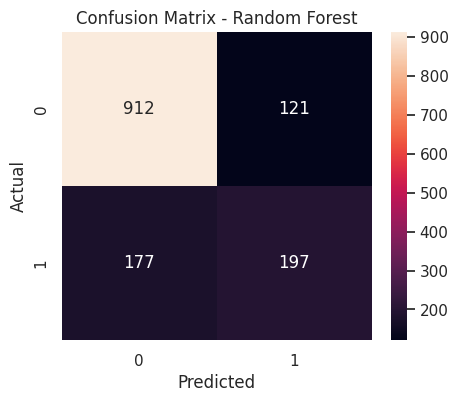

In [80]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [81]:
#4.6: ROC CURVE

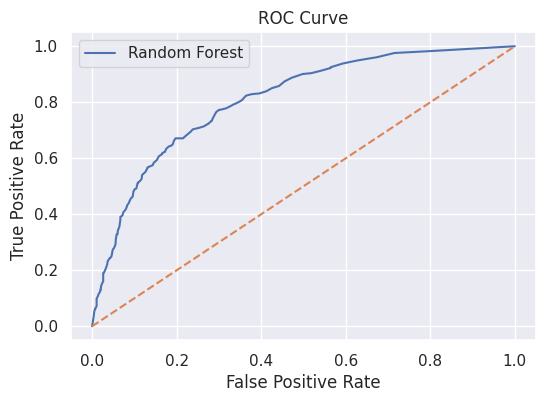

In [82]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Random Forest outperforms Logistic Regression in terms of ROC-AUC and recall, suggesting it captures non-linear relationships in customer behavior more effectively. However, Logistic Regression remains more interpretable and may still be useful for baseline comparison.

# Step 5: Model Explainability
## Objective: Understand the main drivers of churn and interpret individual predictions

## Question to answer:

Why is the model predicting churn?

The goal is not only to predict churn, but also to provide interpretability by:

- Identifying the most influential features  
- Explaining why individual customers are at risk  
- Translating model outputs into actionable business insights  

In [83]:
#5.1: FEATURE IMPORTANCE -- RANDOM FOREST CLASSIFIER

In [84]:
# get transformed feature names
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# get importances from random forest
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
2,num__TotalCharges,0.260674
1,num__MonthlyCharges,0.244615
0,num__tenure,0.194545
3,cat__Contract_Month-to-month,0.060651
7,cat__InternetService_Fiber optic,0.040542
11,cat__PaymentMethod_Electronic check,0.030175
5,cat__Contract_Two year,0.026777
8,cat__InternetService_No,0.015826
13,cat__PaperlessBilling_No,0.014029
16,cat__OnlineSecurity_1,0.012827


In [85]:
#Top 10 Features Visualization

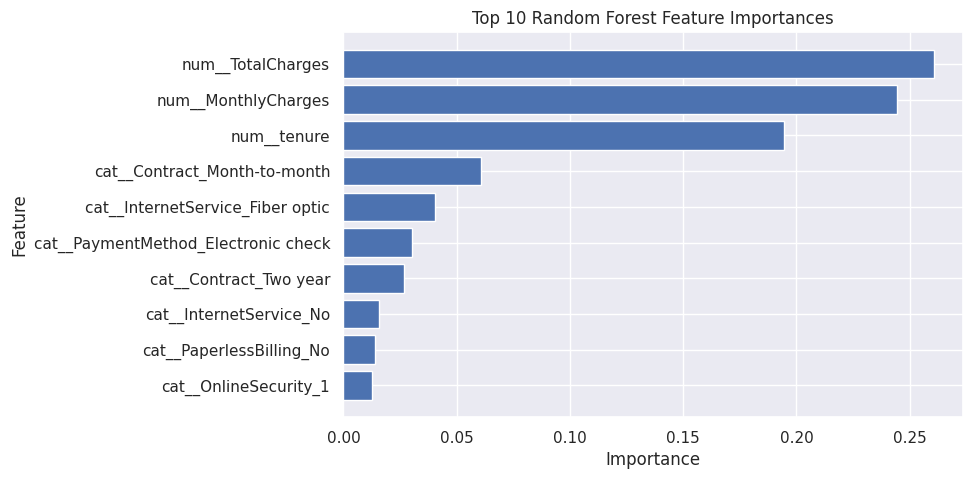

In [86]:
top10 = importance_df.head(10).sort_values(by='importance')

plt.figure(figsize=(8,5))
plt.barh(top10['feature'], top10['importance'])
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The Random Forest model highlights the most influential variables behind churn predictions. Contract type, tenure, monthly charges, and service-related features appear among the strongest predictors, confirming patterns already observed during EDA.

In [87]:
#5.2: COEFFICIENTS -- LOGISTIC REGRESSION

In [88]:
lr_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
lr_coefficients = lr_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature': lr_feature_names,
    'coefficient': lr_coefficients
}).sort_values(by='coefficient', ascending=False)

coef_df.head(10), coef_df.tail(10)

(                                feature  coefficient
 2                     num__TotalCharges     0.705576
 3          cat__Contract_Month-to-month     0.515008
 7      cat__InternetService_Fiber optic     0.440705
 1                   num__MonthlyCharges     0.144311
 11  cat__PaymentMethod_Electronic check     0.143539
 15                cat__OnlineSecurity_0    -0.072086
 6              cat__InternetService_DSL    -0.096620
 17                   cat__TechSupport_0    -0.113361
 14            cat__PaperlessBilling_Yes    -0.163650
 12      cat__PaymentMethod_Mailed check    -0.254964,
                                          feature  coefficient
 12               cat__PaymentMethod_Mailed check    -0.254964
 10    cat__PaymentMethod_Credit card (automatic)    -0.255989
 4                         cat__Contract_One year    -0.273166
 9   cat__PaymentMethod_Bank transfer (automatic)    -0.303982
 13                      cat__PaperlessBilling_No    -0.507746
 18                        

In [89]:
#Visualization of Negative and Positive Coefficients

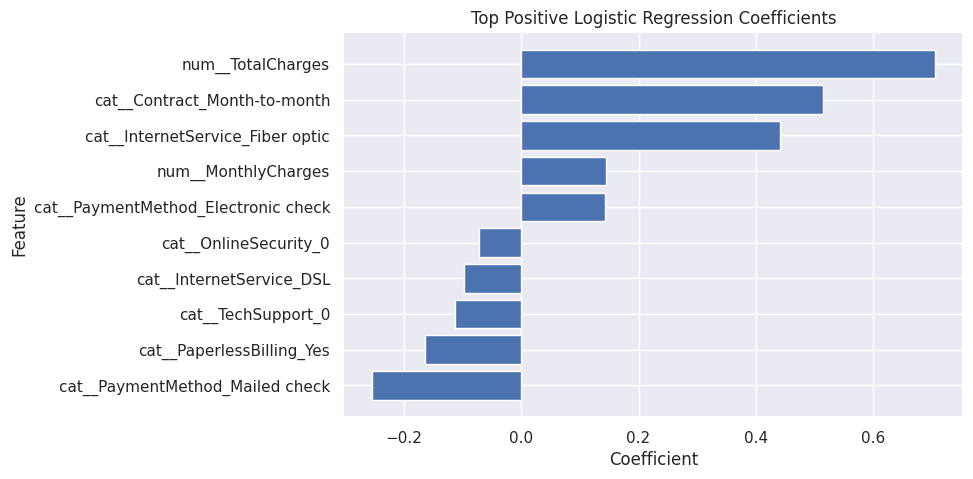

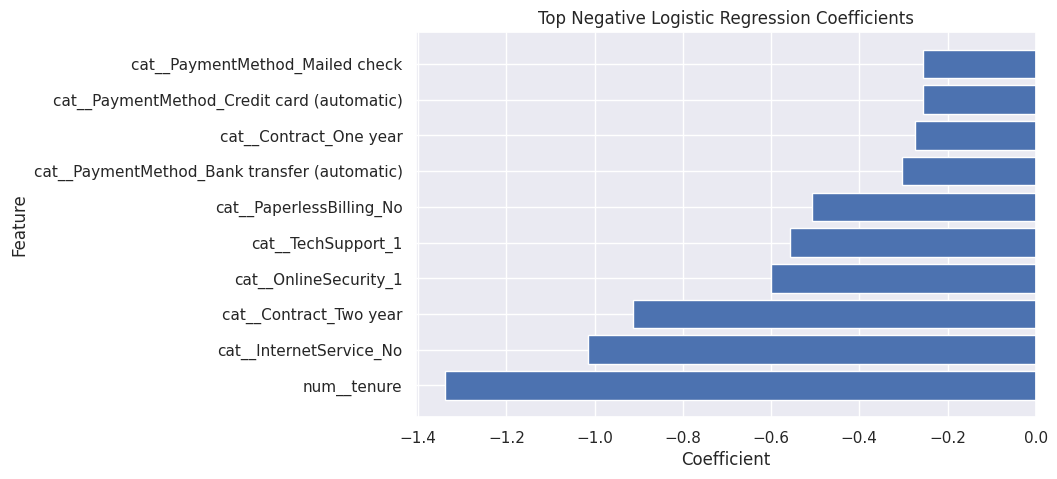

In [90]:
top_positive = coef_df.head(10).sort_values(by='coefficient')
top_negative = coef_df.tail(10).sort_values(by='coefficient')

plt.figure(figsize=(8,5))
plt.barh(top_positive['feature'], top_positive['coefficient'])
plt.title('Top Positive Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

plt.figure(figsize=(8,5))
plt.barh(top_negative['feature'], top_negative['coefficient'])
plt.title('Top Negative Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

Logistic Regression provides a transparent view of churn drivers. Positive coefficients indicate features associated with higher churn risk, while negative coefficients point to retention-related characteristics.

In [91]:
#5.3: SHAP INSTALLATION AND IMPORTS

In [92]:
!pip install shap

In [93]:
import shap

In [94]:
#5.4: PREPARE TRANSFORMED DATA FOR SHAP & SHAP VALUES

In [95]:
X_test_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)
rf_model = rf_pipeline.named_steps['model']

explainer = shap.Explainer(rf_model)
shap_exp = explainer(X_test_transformed)

print(shap_exp.values.shape)

(1407, 19, 2)


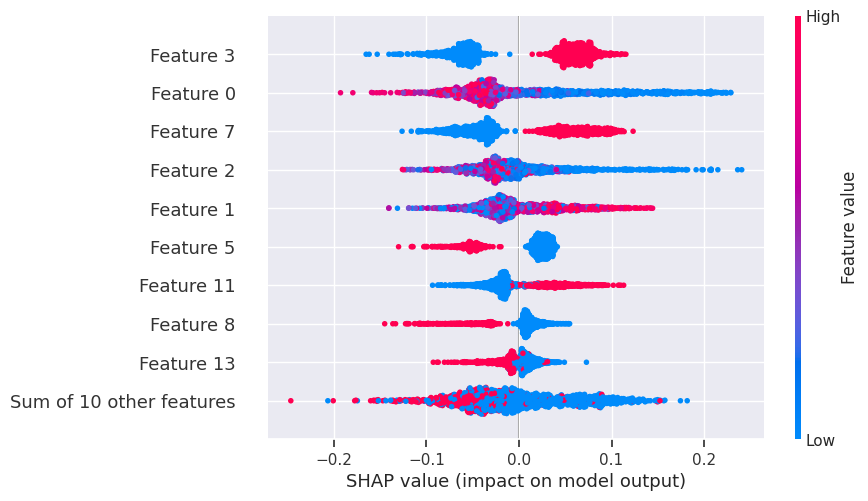

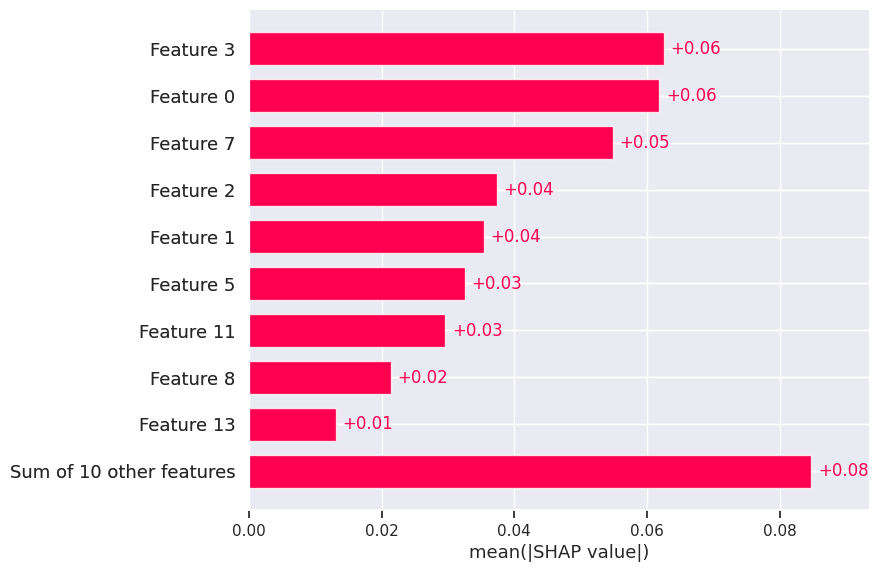

In [96]:
shap_class1 = shap_exp[:, :, 1]

shap.plots.beeswarm(shap_class1, max_display=10)
shap.plots.bar(shap_class1, max_display=10)

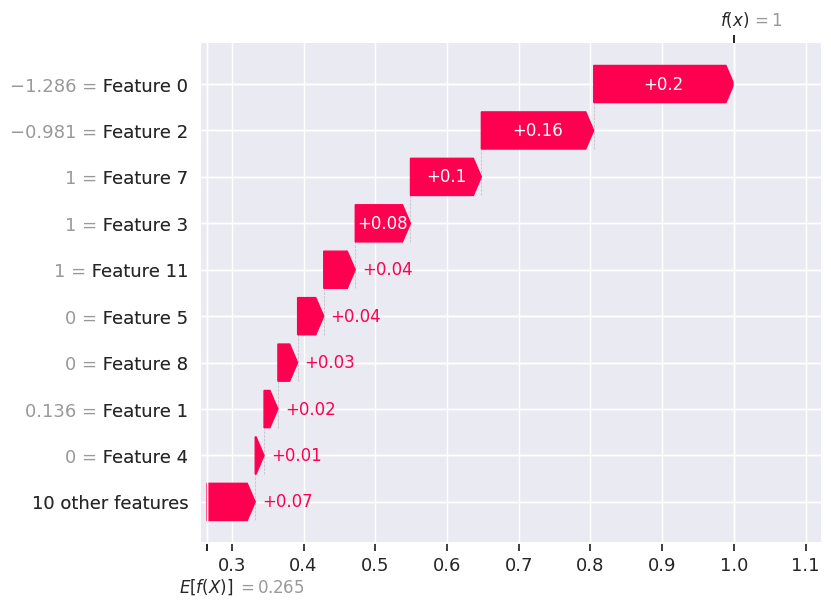

In [97]:
top_idx = np.argmax(y_prob_rf)
shap.plots.waterfall(shap_class1[top_idx], max_display=10)

## Insights

1. Contract type is one of the strongest churn drivers
2. Short tenure strongly increases churn risk
3. Higher monthly charges are associated with greater churn probability
4. Service adoption features such as tech support or online security help explain retention

## Summary of Step 5

SHAP explainability was applied to the churn class specifically, allowing the analysis to focus on the factors that increase or decrease the probability of customer churn.

# Step 6: Business Action Layer
## Objective: Translate churn predictions into targeted retention actions

## Objective

Translate churn probabilities into actionable decisions by determining:

- Which customers should be prioritized for intervention  
- What type of retention strategy should be applied  
- How to allocate retention budget efficiently across customers  

## Business Logic

The approach is straightforward:

- High-risk, high-value customers → prioritized and intensive retention actions  
- High-risk, medium-value customers → standard retention interventions  
- High-risk, low-value customers → low-cost or automated actions  
- Low-risk customers → monitoring and no immediate intervention  

In [98]:
#6.1: OPERATIVE TABLE

In [99]:
risk_df = X_test.copy()
risk_df['actual_churn'] = y_test.values
risk_df['predicted_churn'] = y_pred_rf
risk_df['churn_probability'] = y_prob_rf

In [100]:
#6.2: RISK TIERS

In [101]:
def risk_segment(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.45:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['risk_segment'] = risk_df['churn_probability'].apply(risk_segment)

In [102]:
#6.3: CUSTOMER VALUE TIERS

In [103]:
risk_df['value_segment'] = pd.qcut(
    risk_df['avg_monthly_value'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [104]:
#6.4: ACTION RULES

In [105]:
def retention_action(row):
    if row['risk_segment'] == 'High Risk' and row['value_segment'] == 'High Value':
        return 'Priority retention offer'
    elif row['risk_segment'] == 'High Risk' and row['value_segment'] == 'Medium Value':
        return 'Personalized email + support call'
    elif row['risk_segment'] == 'High Risk' and row['value_segment'] == 'Low Value':
        return 'Automated retention email'
    elif row['risk_segment'] == 'Medium Risk' and row['value_segment'] == 'High Value':
        return 'Proactive engagement campaign'
    elif row['risk_segment'] == 'Medium Risk':
        return 'Monitor and nurture'
    else:
        return 'No immediate action'

risk_df['recommended_action'] = risk_df.apply(retention_action, axis=1)

In [106]:
#6.5: A SNEAK PEAK INTO THE RESULTS

In [107]:
risk_df[[
    'churn_probability',
    'risk_segment',
    'value_segment',
    'recommended_action'
]].head(10)

,churn_probability,risk_segment,value_segment,recommended_action
974,0.01,Low Risk,High Value,No immediate action
619,0.77,High Risk,Medium Value,Personalized email + support call
4289,0.00,Low Risk,Low Value,No immediate action
3721,0.03,Low Risk,Low Value,No immediate action
4533,0.33,Low Risk,High Value,No immediate action
445,0.13,Low Risk,High Value,No immediate action
5898,0.00,Low Risk,Low Value,No immediate action
3387,0.01,Low Risk,Low Value,No immediate action
1346,0.56,Medium Risk,High Value,Proactive engagement campaign
5690,0.02,Low Risk,Medium Value,No immediate action


In [108]:
#6.6: HOW MANY CLIENTS PER ACTION?

In [109]:
action_counts = risk_df['recommended_action'].value_counts()
print(action_counts)

recommended_action
No immediate action                  1039
Monitor and nurture                   137
Proactive engagement campaign          74
Personalized email + support call      69
Automated retention email              55
Priority retention offer               33
Name: count, dtype: int64


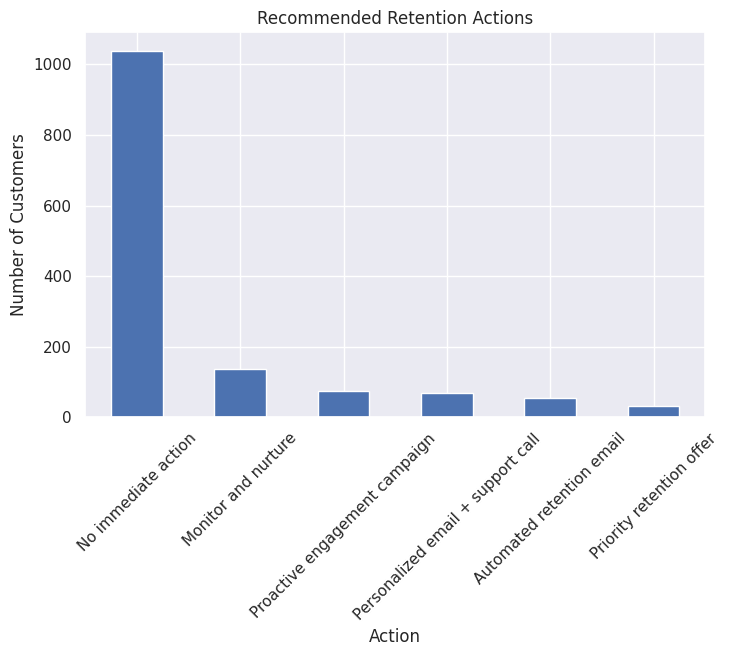

In [110]:
plt.figure(figsize=(8,5))
action_counts.plot(kind='bar')
plt.title('Recommended Retention Actions')
plt.xlabel('Action')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [111]:
#6.7: TOP HIGH-PRIORITY CUSTOMERS

In [112]:
priority_customers = risk_df[
    (risk_df['risk_segment'] == 'High Risk') &
    (risk_df['value_segment'] == 'High Value')
].sort_values(by='churn_probability', ascending=False)

priority_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,engagement_score,is_monthly_contract,high_monthly_charges,is_auto_payment,actual_churn,predicted_churn,churn_probability,risk_segment,value_segment,recommended_action
886,Female,1,No,No,7,Yes,No,Fiber optic,0,0,...,2,1,1,0,0,1,1.00,High Risk,High Value,Priority retention offer
2797,Male,0,No,No,3,Yes,Yes,Fiber optic,0,0,...,3,1,1,0,1,1,1.00,High Risk,High Value,Priority retention offer
3545,Female,0,No,No,50,Yes,Yes,Fiber optic,0,0,...,2,1,1,0,0,1,0.99,High Risk,High Value,Priority retention offer
6839,Female,0,No,No,11,Yes,Yes,Fiber optic,0,0,...,3,1,1,0,1,1,0.99,High Risk,High Value,Priority retention offer
4335,Female,1,No,No,18,Yes,No,Fiber optic,0,0,...,2,1,1,0,0,1,0.98,High Risk,High Value,Priority retention offer
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,0,0,...,3,1,1,0,1,1,0.98,High Risk,High Value,Priority retention offer
3085,Male,0,No,No,3,Yes,Yes,Fiber optic,0,1,...,4,1,1,1,1,1,0.96,High Risk,High Value,Priority retention offer
6838,Male,0,No,No,13,Yes,Yes,Fiber optic,0,0,...,3,1,1,0,1,1,0.91,High Risk,High Value,Priority retention offer
3159,Male,1,No,No,3,Yes,Yes,Fiber optic,0,0,...,2,1,1,0,0,1,0.91,High Risk,High Value,Priority retention offer
5413,Female,0,No,No,15,Yes,No,Fiber optic,0,0,...,3,1,1,1,0,1,0.89,High Risk,High Value,Priority retention offer


In [113]:
#6.8: EXECUTIVE SUMMARY TABLE

In [114]:
summary_table = risk_df.groupby(
    ['risk_segment', 'value_segment', 'recommended_action']
).size().reset_index(name='customer_count')

summary_table

/tmp/ipykernel_4836/2551850539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = risk_df.groupby(


,risk_segment,value_segment,recommended_action,customer_count
0,High Risk,Low Value,Automated retention email,55
1,High Risk,Low Value,Monitor and nurture,0
2,High Risk,Low Value,No immediate action,0
3,High Risk,Low Value,Personalized email + support call,0
4,High Risk,Low Value,Priority retention offer,0
5,High Risk,Low Value,Proactive engagement campaign,0
6,High Risk,Medium Value,Automated retention email,0
7,High Risk,Medium Value,Monitor and nurture,0
8,High Risk,Medium Value,No immediate action,0
9,High Risk,Medium Value,Personalized email + support call,69


## Insights

1. Not all churn-risk customers should be treated equally
2. Retention resources should focus first on high-risk, high-value customers
3. Lower-value customers can be handled through automated or lower-cost actions

## Summary of Step 6

The churn model was translated into an action framework by combining predicted churn probability with customer value. This allows the business to prioritize high-risk, high-value customers for retention efforts while using lower-cost interventions for lower-value segments.

## Extra (Step 6): Action per Client Type

In [115]:
priority_customers[['Contract', 'MonthlyCharges', 'tenure', 'avg_monthly_value']].head(10)

,Contract,MonthlyCharges,tenure,avg_monthly_value
886,Month-to-month,84.35,7,76.206250
2797,Month-to-month,100.95,3,82.487500
3545,Month-to-month,95.70,50,92.740196
6839,Month-to-month,100.75,11,94.145833
4335,Month-to-month,84.95,18,75.981579
2631,Month-to-month,99.25,7,83.181250
3085,Month-to-month,105.35,3,80.812500
6838,Month-to-month,99.00,13,92.978571
3159,Month-to-month,94.85,3,83.937500
5413,Month-to-month,94.00,15,94.090625


This step bridges predictive modeling and business execution by turning churn probabilities into segment-based retention recommendations. Instead of treating all at-risk customers the same way, the framework prioritizes interventions according to both churn risk and customer value.

# Step 7: Profit and ROI Simulation
## Objective: Estimate the financial impact of churn prediction and retention actions

In this step, we evaluate:

- The cost associated with each retention action  
- The expected value preserved through customer retention  
- Which strategy delivers the highest return and overall effectiveness  

## Objective

Show that the model delivers value beyond prediction by enabling:

- Reduction in customer churn  
- Preservation of customer lifetime value and revenue  
- Optimization of the ROI of retention strategies  

## Business Logic

In this step, we implement a simplified yet impactful simulation framework:

- Each retention action incurs a specific cost  
- Each customer is associated with an economic value  
- Retention actions have an estimated probability of success  

Based on these assumptions, we estimate:

- Total intervention cost  
- Number of customers retained  
- Expected revenue preserved  
- Net profit generated  
- Overall return on investment (ROI)  

In [116]:
#7.1: DEFINE RETENTION COSTS AND SUCCESS RATES

In [117]:
action_costs = {
    'Priority retention offer': 80,
    'Personalized email + support call': 30,
    'Automated retention email': 5,
    'Proactive engagement campaign': 15,
    'Monitor and nurture': 3,
    'No immediate action': 0
}

action_success = {
    'Priority retention offer': 0.35,
    'Personalized email + support call': 0.25,
    'Automated retention email': 0.10,
    'Proactive engagement campaign': 0.15,
    'Monitor and nurture': 0.05,
    'No immediate action': 0.00
}

In [118]:
#7.2: ESTIMATE CUSTOMER VALUE

In [119]:
risk_df['estimated_customer_value'] = risk_df['avg_monthly_value'] * 12

In [120]:
#7.3: ASSIGN COSTS AND SUCCESS PROBABILITY

In [121]:
risk_df['action_cost'] = risk_df['recommended_action'].map(action_costs)
risk_df['action_success_rate'] = risk_df['recommended_action'].map(action_success)

In [122]:
#7.4: ESTIMATION EXPECTED SAVED VALUE

In [123]:
risk_df['expected_saved_value'] = (
    risk_df['churn_probability'] *
    risk_df['action_success_rate'] *
    risk_df['estimated_customer_value']
)

In [124]:
#7.5: EXPECTED NET VALUE

In [125]:
risk_df['expected_net_value'] = risk_df['expected_saved_value'] - risk_df['action_cost']

In [126]:
#7.6: SUMMARY RESULTS

In [127]:
total_cost = risk_df['action_cost'].sum()
total_saved_value = risk_df['expected_saved_value'].sum()
total_net_profit = risk_df['expected_net_value'].sum()

roi = total_net_profit / total_cost if total_cost > 0 else 0

print("Total retention cost:", round(total_cost, 2))
print("Total expected saved value:", round(total_saved_value, 2))
print("Total expected net profit:", round(total_net_profit, 2))
print("ROI:", round(roi, 2))

Total retention cost: 6506
Total expected saved value: 32347.76
Total expected net profit: 25841.76
ROI: 3.97


In [128]:
#7.7: RESULTS PER ACTION

In [129]:
roi_summary = risk_df.groupby('recommended_action').agg(
    customers=('recommended_action', 'count'),
    total_cost=('action_cost', 'sum'),
    total_saved_value=('expected_saved_value', 'sum'),
    total_net_value=('expected_net_value', 'sum')
).reset_index()

roi_summary['roi'] = roi_summary['total_net_value'] / roi_summary['total_cost'].replace(0, np.nan)

roi_summary.sort_values(by='total_net_value', ascending=False)

,recommended_action,customers,total_cost,total_saved_value,total_net_value,roi
3,Personalized email + support call,69,2070,10842.268865,8772.268865,4.237811
4,Priority retention offer,33,2640,10617.587298,7977.587298,3.021813
5,Proactive engagement campaign,74,1110,6992.869195,5882.869195,5.299882
1,Monitor and nurture,137,411,2271.744141,1860.744141,4.527358
0,Automated retention email,55,275,1623.294047,1348.294047,4.902887
2,No immediate action,1039,0,0.000000,0.000000,NaN


In [130]:
#7.8: TOTAL NET VALUE PER ACTION VISUALIZATION

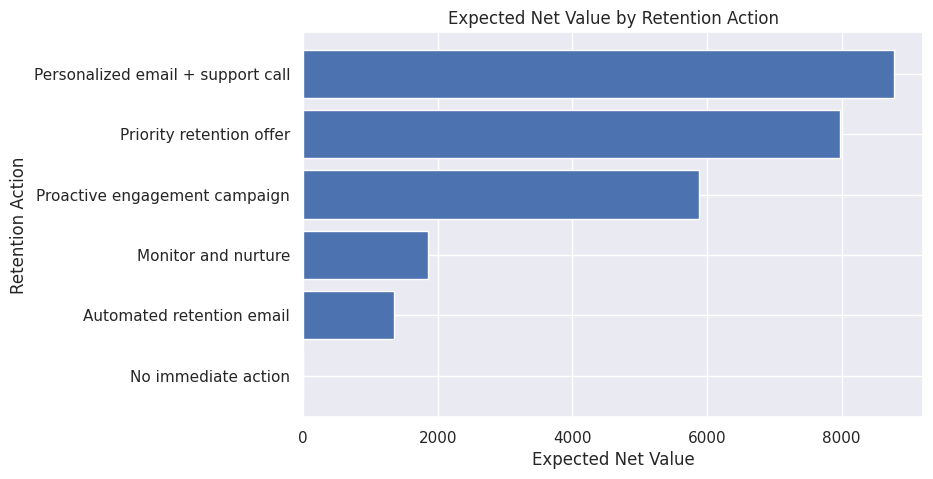

In [131]:
roi_plot = roi_summary.sort_values(by='total_net_value', ascending=True)

plt.figure(figsize=(8,5))
plt.barh(roi_plot['recommended_action'], roi_plot['total_net_value'])
plt.title('Expected Net Value by Retention Action')
plt.xlabel('Expected Net Value')
plt.ylabel('Retention Action')
plt.show()

In [132]:
#TOP CLIENTS PER EXPECTED NET VALUE

In [133]:
top_roi_customers = risk_df.sort_values(by='expected_net_value', ascending=False)
top_roi_customers[[
    'churn_probability',
    'risk_segment',
    'value_segment',
    'recommended_action',
    'estimated_customer_value',
    'expected_saved_value',
    'expected_net_value'
]].head(10)

,churn_probability,risk_segment,value_segment,recommended_action,estimated_customer_value,expected_saved_value,expected_net_value
6839,0.99,High Risk,High Value,Priority retention offer,1129.750000,391.458375,311.458375
3545,0.99,High Risk,High Value,Priority retention offer,1112.882353,385.613735,305.613735
1457,0.83,High Risk,High Value,Priority retention offer,1279.855814,371.798114,291.798114
6838,0.91,High Risk,High Value,Priority retention offer,1115.742857,355.364100,275.364100
5413,0.89,High Risk,High Value,Priority retention offer,1129.087500,351.710756,271.710756
6962,0.85,High Risk,High Value,Priority retention offer,1180.478571,351.192375,271.192375
3063,0.83,High Risk,High Value,Priority retention offer,1203.331579,349.567824,269.567824
2797,1.00,High Risk,High Value,Priority retention offer,989.850000,346.447500,266.447500
3783,0.79,High Risk,High Value,Priority retention offer,1242.420896,343.529378,263.529378
2631,0.98,High Risk,High Value,Priority retention offer,998.175000,342.374025,262.374025


In [134]:
#STRATEGIC COMPARISON: INTERVENE VS. DO NOTHING

In [135]:
intervention_value = risk_df['expected_net_value'].sum()

do_nothing_value = 0

print("Expected value with intervention:", round(intervention_value, 2))
print("Expected value with no action:", round(do_nothing_value, 2))
print("Lift from retention strategy:", round(intervention_value - do_nothing_value, 2))

Expected value with intervention: 25841.76
Expected value with no action: 0
Lift from retention strategy: 25841.76


## Summary of Step 7

The ROI simulation shows that churn prediction can support not only better targeting but also better financial decisions. By combining churn risk, customer value, intervention cost, and estimated success rates, the project translates model output into an expected business return.

## Insights

1. High-risk, high-value customers generate the largest expected return from intervention
2. Not every retention action is equally profitable
3. Low-cost automated actions can still create positive value at scale
4. A targeted retention strategy outperforms a generic one-size-fits-all approach

The final simulation demonstrates how a churn model can be operationalized into a financially meaningful retention strategy. Rather than stopping at prediction, the project estimates the economic value of acting on churn risk, making the analysis more relevant for real business decision-making.

## Note

This ROI analysis is based on simplified business assumptions regarding intervention costs and retention success rates. Its purpose is not to provide exact financial forecasts, but to demonstrate how churn predictions can be translated into economically informed decision-making.

# Key Findings and Recommendations
## Objective: Summarize the main insights and translate them into actionable business decisions

## Key Findings

The analysis reveals that customer churn is not random but driven by identifiable behavioral and contractual patterns. The most important factors associated with churn include:

1. Short customer tenure, indicating that early-stage retention is critical
2. Month-to-month contracts, which significantly increase churn risk
3. Higher monthly charges, suggesting price sensitivity or perceived value issues
4. Low engagement with additional services, such as online security and tech support

Both the Random Forest model and SHAP analysis confirm that these variables are strong predictors of churn, highlighting consistent patterns between exploratory analysis and model behavior.

## Business Implications

These findings have direct implications for customer retention strategy:

1. Churn is heavily concentrated among new and less-engaged customers, making onboarding and early engagement key priorities
2. Customers on flexible contracts (month-to-month) represent the most vulnerable segment
3. Pricing structure and perceived value play an important role in customer decisions
4. Increasing customer engagement through service adoption may act as a natural retention mechanism

Overall, churn should not be addressed uniformly, but through segmented and targeted interventions.

## Strategic Recommendations

Based on the predictive model and ROI simulation, the following strategic recommendations are proposed:

1. Prioritize High-Risk, High-Value Customers

Retention efforts should focus first on customers who are both likely to churn and generate high value. These customers provide the highest expected return on intervention.

2. Strengthen Early Customer Lifecycle Engagement

Since churn risk is highest during the early stages of tenure, onboarding strategies and early engagement campaigns should be enhanced.

3. Incentivize Long-Term Contracts

Customers on month-to-month plans are significantly more likely to churn. Offering incentives to transition to longer-term contracts could reduce churn rates.

4. Increase Service Adoption

Customers using additional services (e.g., tech support, online security) show lower churn rates. Promoting these services can improve retention.

5. Optimize Retention Budget Allocation

The ROI simulation demonstrates that not all interventions are equally profitable. Retention strategies should be optimized by balancing cost, success probability, and customer value.

6. Implement a Data-Driven Retention System

The churn model can be operationalized into a real-time decision system that continuously identifies at-risk customers and recommends targeted actions.

## Limitations

This analysis is based on historical data and simplified assumptions regarding retention costs and success rates. Real-world performance may vary depending on execution quality, customer behavior changes, and market conditions. Future work could include A/B testing of retention strategies and continuous model retraining.

## Next Steps

Future improvements could include:

1. Deploying the model as a real-time scoring system
2. Integrating customer feedback and behavioral data
3. Running controlled experiments (A/B tests) to validate retention strategies
4. Enhancing the model with more advanced algorithms (e.g., Gradient Boosting, XGBoost)

> This project demonstrates how machine learning can move beyond prediction and become a practical decision-making tool, directly supporting business strategy and customer retention efforts.